# Klasifikasi Koin Rupiah dengan Transfer Learning

Mengklasifikasikan koin rupiah berdasarkan nominal DAN sisi koin (8 kelas):
- Rp 100 Angka, Rp 100 Gambar
- Rp 200 Angka, Rp 200 Gambar  
- Rp 500 Angka, Rp 500 Gambar
- Rp 1000 Angka, Rp 1000 Gambar

## Metode: Transfer Learning dengan Pre-trained Models

Notebook ini menggunakan **Transfer Learning** dengan model pre-trained (ResNet18, MobileNetV2) yang sudah dilatih pada ImageNet. Berbeda dengan CNN custom sebelumnya yang menggunakan edge detection, Transfer Learning memanfaatkan fitur yang sudah dipelajari dari jutaan gambar.

### Perbandingan Pendekatan:
| Aspek | CNN Custom + Edge Detection | Transfer Learning |
|-------|---------------------------|-------------------|
| Input | Grayscale edge image (256×256×1) | RGB image (224×224×3) |
| Training | From scratch | Fine-tuning pre-trained weights |
| Data Required | Banyak | Lebih sedikit |
| Training Time | Lama | Lebih cepat |

**Dokumentasi lengkap**: Lihat [COIN-README.md](./COIN-README.md)

## 1. Import Libraries

In [1]:
import sys
import os
from pathlib import Path
import time

# Add src to path
sys.path.append(str(Path('../src').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# PyTorch for Transfer Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm import tqdm

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU tidak tersedia, menggunakan CPU")

PyTorch version: 2.7.1+cu118
Device: cuda
GPU: NVIDIA GeForce RTX 2060


## 2. Setup Paths dan Konfigurasi

Dataset: `dataset_splitted` dengan 8 kelas (4 nominal × 2 sisi).  
Image size **224×224** (standar untuk pre-trained ImageNet models).

**Perbedaan dengan CNN Custom:**
- Menggunakan gambar RGB asli (bukan edge detection)
- Transfer Learning dari model pre-trained ImageNet

In [2]:
# Directories
BASE_DIR = Path('..').resolve()
DATASET_DIR = BASE_DIR / 'dataset_splitted'  # Using splitted dataset (8 classes)
RESULTS_DIR = BASE_DIR / 'results' / 'coin_classification_transfer_learning'
MODELS_DIR = BASE_DIR / 'models'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'confusion_matrix').mkdir(exist_ok=True)
(RESULTS_DIR / 'visualizations').mkdir(exist_ok=True)

# Configuration
IMAGE_SIZE = (224, 224)  # Standard ImageNet size for pre-trained models
MAX_IMAGES_PER_CLASS = None  # Set to None for unlimited
RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15
EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.0001  # Lower learning rate for fine-tuning

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print(f"Dataset: {DATASET_DIR}")
print(f"Results: {RESULTS_DIR}")
print(f"Config: {IMAGE_SIZE}, max {MAX_IMAGES_PER_CLASS or 'unlimited'} imgs/class")
print(f"Training: {EPOCHS} epochs, batch size {BATCH_SIZE}, lr {LEARNING_RATE}")

Dataset: D:\dev\semester5\pengolahan-citra\projek-edge-detection\dataset_splitted
Results: D:\dev\semester5\pengolahan-citra\projek-edge-detection\results\coin_classification_transfer_learning
Config: (224, 224), max unlimited imgs/class
Training: 5 epochs, batch size 32, lr 0.0001


## 3. Dataset Class dan Transformasi

Untuk Transfer Learning, kita menggunakan:
- **Gambar RGB** (bukan edge detection)
- **Normalisasi ImageNet** (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
- **Data Augmentation** saat training (random crop, flip, rotation, color jitter)

In [3]:
class CoinDataset(Dataset):
    """Dataset class untuk klasifikasi koin dengan Transfer Learning."""
    
    def __init__(self, image_paths, labels, transform=None, class_names=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.class_names = class_names
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load image dengan PIL (untuk kompatibilitas dengan torchvision transforms)
            image = Image.open(img_path).convert('RGB')
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            
            return image, label
        
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return dummy image if error
            dummy_img = torch.randn(3, 224, 224)
            return dummy_img, label


def get_transforms(phase='train'):
    """
    Get transforms untuk setiap phase (train/val/test).
    
    Menggunakan normalisasi ImageNet standard untuk pre-trained models.
    """
    # ImageNet normalization
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    
    if phase == 'train':
        return transforms.Compose([
            transforms.Resize((256, 256)),  # Resize larger first
            transforms.RandomCrop((224, 224)),  # Then random crop
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    else:  # val/test - no augmentation
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])


def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize tensor untuk visualisasi"""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clamp(0, 1)

## 4. Load Dataset dan Buat DataLoader

In [4]:
def load_dataset_paths(dataset_dir, class_names, max_images=None):
    """
    Load semua image paths dan labels dari dataset.
    
    Args:
        dataset_dir: Path ke dataset
        class_names: List nama kelas
        max_images: Maksimum gambar per kelas
    
    Returns:
        all_paths: List path gambar
        all_labels: List label
    """
    all_paths = []
    all_labels = []
    
    for label, cls_name in enumerate(class_names):
        # Parse class name: "Koin Rp 100 - angka" -> "Koin Rp 100/angka"
        parts = cls_name.rsplit(' - ', 1)
        coin_type, side = parts[0], parts[1]
        cls_dir = dataset_dir / coin_type / side
        
        # Get all image files
        images = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            images.extend(list(cls_dir.glob(ext)))
        
        # Limit if specified
        if max_images is not None and len(images) > max_images:
            np.random.shuffle(images)
            images = images[:max_images]
        
        print(f"{cls_name}: {len(images)} images")
        
        all_paths.extend([str(p) for p in images])
        all_labels.extend([label] * len(images))
    
    return all_paths, all_labels


# Build class names
print("="*60)
print("LOADING DATASET")
print("="*60)

class_names = []
coin_types = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])

for coin_type in coin_types:
    coin_dir = DATASET_DIR / coin_type
    sides = sorted([s.name for s in coin_dir.iterdir() if s.is_dir()])
    for side in sides:
        class_name = f"{coin_type} - {side}"
        class_names.append(class_name)

print(f"\nTotal Classes: {len(class_names)}")
print(f"Classes: {class_names}\n")

# Load all paths
all_paths, all_labels = load_dataset_paths(DATASET_DIR, class_names, MAX_IMAGES_PER_CLASS)
print(f"\nTotal images: {len(all_paths)}")

LOADING DATASET

Total Classes: 8
Classes: ['Koin Rp 100 - angka', 'Koin Rp 100 - gambar', 'Koin Rp 1000 - angka', 'Koin Rp 1000 - gambar', 'Koin Rp 200 - angka', 'Koin Rp 200 - gambar', 'Koin Rp 500 - angka', 'Koin Rp 500 - gambar']

Koin Rp 100 - angka: 140 images
Koin Rp 100 - gambar: 116 images
Koin Rp 1000 - angka: 268 images
Koin Rp 1000 - gambar: 112 images
Koin Rp 200 - angka: 132 images
Koin Rp 200 - gambar: 138 images
Koin Rp 500 - angka: 236 images
Koin Rp 500 - gambar: 118 images

Total images: 1260


## 5. Split Data dan Buat DataLoader

In [5]:
# Split: Train (70%), Val (15%), Test (15%)
print("\n" + "="*60)
print("SPLITTING DATASET")
print("="*60)

# First split: train+val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

# Second split: train vs val
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_ratio,
    random_state=RANDOM_SEED,
    stratify=y_train_val
)

print(f"\nDataset Split:")
print(f"  Training:   {len(X_train)} images ({len(X_train)/len(all_paths)*100:.1f}%)")
print(f"  Validation: {len(X_val)} images ({len(X_val)/len(all_paths)*100:.1f}%)")
print(f"  Test:       {len(X_test)} images ({len(X_test)/len(all_paths)*100:.1f}%)")

# Distribusi per kelas
print("\nDistribusi per split:")
for split_name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = [labels.count(i) for i in range(len(class_names))]
    print(f"  {split_name}: {dict(zip([c.split(' - ')[0][-3:] + '-' + c.split(' - ')[1][0] for c in class_names], counts))}")


SPLITTING DATASET

Dataset Split:
  Training:   819 images (65.0%)
  Validation: 189 images (15.0%)
  Test:       252 images (20.0%)

Distribusi per split:
  Train: {'100-a': 91, '100-g': 76, '000-a': 174, '000-g': 73, '200-a': 86, '200-g': 89, '500-a': 154, '500-g': 76}
  Val: {'100-a': 21, '100-g': 17, '000-a': 40, '000-g': 17, '200-a': 20, '200-g': 21, '500-a': 35, '500-g': 18}
  Test: {'100-a': 28, '100-g': 23, '000-a': 54, '000-g': 22, '200-a': 26, '200-g': 28, '500-a': 47, '500-g': 24}


## 6. Buat Dataset dan DataLoader

In [6]:
# Create datasets
train_dataset = CoinDataset(X_train, y_train, transform=get_transforms('train'), class_names=class_names)
val_dataset = CoinDataset(X_val, y_val, transform=get_transforms('val'), class_names=class_names)
test_dataset = CoinDataset(X_test, y_test, transform=get_transforms('test'), class_names=class_names)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("\nDataLoader Created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Verify first batch
for images, labels in train_loader:
    print(f"\nSample batch:")
    print(f"  Images shape: {images.shape}")  # Should be [batch, 3, 224, 224]
    print(f"  Labels shape: {labels.shape}")
    print(f"  Labels sample: {labels[:5].tolist()}")
    break


DataLoader Created:
  Batch size: 32
  Training batches: 26
  Validation batches: 6
  Test batches: 8

Sample batch:
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Labels sample: [6, 0, 0, 5, 6]

Sample batch:
  Images shape: torch.Size([32, 3, 224, 224])
  Labels shape: torch.Size([32])
  Labels sample: [6, 0, 0, 5, 6]


## 7. Visualisasi Sample Dataset

Menampilkan gambar RGB yang akan digunakan untuk Transfer Learning (berbeda dengan edge detection pada CNN custom).

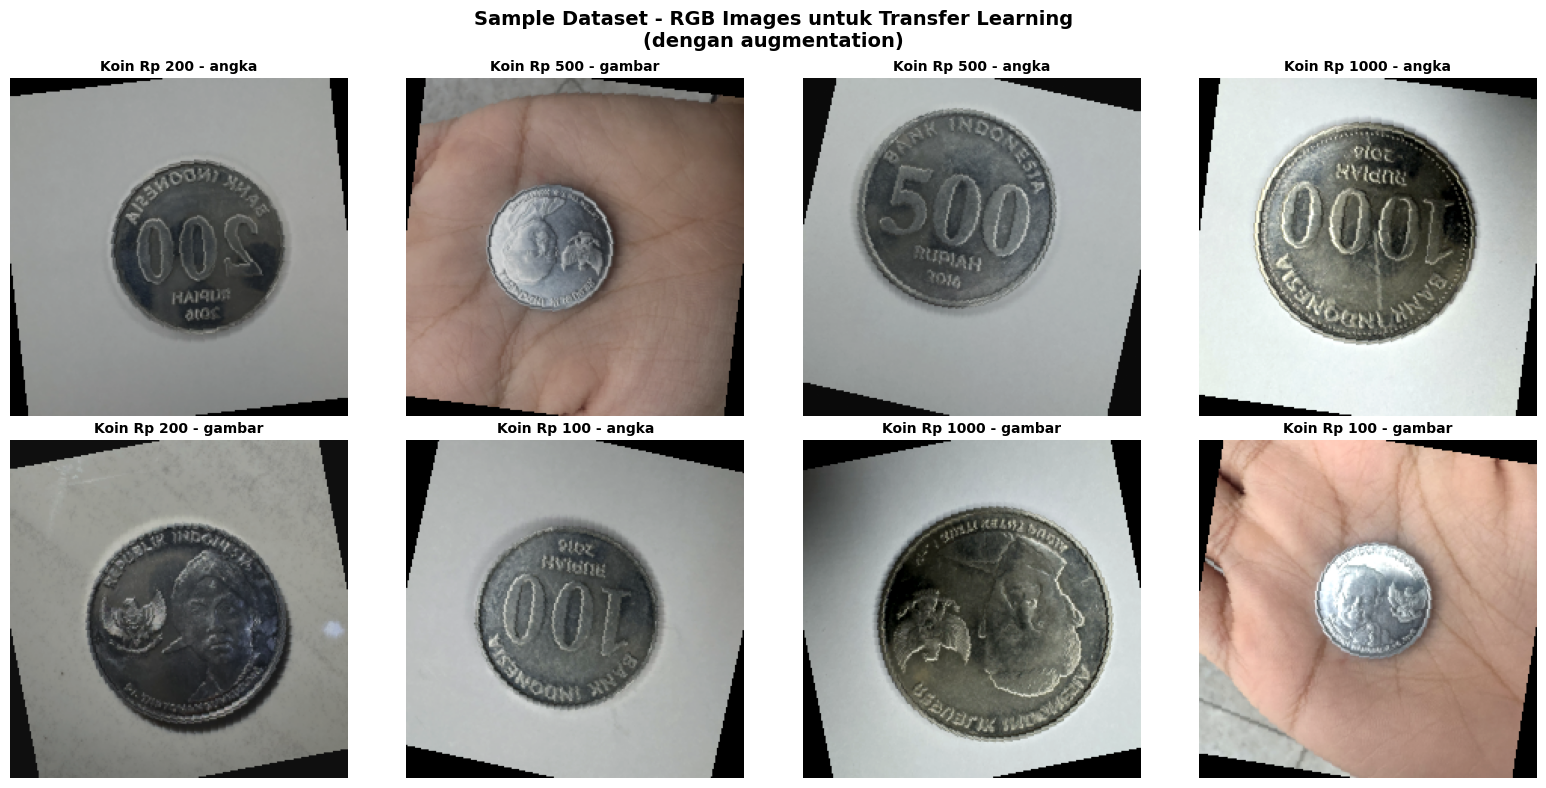

In [7]:
# Visualize sample images from training set
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Get one sample per class
samples_shown = set()
sample_idx = 0

for images, labels in train_loader:
    for i in range(len(labels)):
        label = labels[i].item()
        if label not in samples_shown and sample_idx < 8:
            # Denormalize for visualization
            img = denormalize(images[i])
            img = img.permute(1, 2, 0).numpy()
            
            axes[sample_idx].imshow(img)
            axes[sample_idx].set_title(class_names[label], fontsize=10, fontweight='bold')
            axes[sample_idx].axis('off')
            
            samples_shown.add(label)
            sample_idx += 1
        
        if sample_idx >= 8:
            break
    if sample_idx >= 8:
        break

plt.suptitle('Sample Dataset - RGB Images untuk Transfer Learning\n(dengan augmentation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'visualizations' / 'dataset_samples_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Definisi Model Transfer Learning

Kita akan mencoba 2 arsitektur pre-trained:
1. **ResNet18** - Model populer dengan residual connections
2. **MobileNetV2** - Model ringan, cocok untuk deployment

Strategi Transfer Learning:
- **Freeze** semua layer awal (feature extractor)
- **Unfreeze** beberapa layer terakhir untuk fine-tuning
- **Ganti** fully connected layer terakhir sesuai jumlah kelas kita (8 kelas)

In [8]:
class TransferLearningModel(nn.Module):
    """
    Transfer Learning Model menggunakan pre-trained backbone.
    
    Args:
        model_name: 'resnet18' atau 'mobilenet_v2'
        num_classes: Jumlah kelas output
        freeze_backbone: Freeze semua layer backbone (default True)
        unfreeze_last_n: Unfreeze n layer terakhir backbone
    """
    
    def __init__(self, model_name='resnet18', num_classes=8, freeze_backbone=True, unfreeze_last_n=2):
        super(TransferLearningModel, self).__init__()
        
        self.model_name = model_name
        
        if model_name == 'resnet18':
            # Load pre-trained ResNet18
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            
            # Freeze semua layer
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            # Unfreeze layer terakhir (layer4)
            if unfreeze_last_n > 0:
                for param in self.backbone.layer4.parameters():
                    param.requires_grad = True
                if unfreeze_last_n > 1:
                    for param in self.backbone.layer3.parameters():
                        param.requires_grad = True
            
            # Ganti fully connected layer
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
            
        elif model_name == 'mobilenet_v2':
            # Load pre-trained MobileNetV2
            self.backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            
            # Freeze semua layer
            if freeze_backbone:
                for param in self.backbone.features.parameters():
                    param.requires_grad = False
            
            # Unfreeze beberapa layer terakhir
            if unfreeze_last_n > 0:
                for param in self.backbone.features[-unfreeze_last_n:].parameters():
                    param.requires_grad = True
            
            # Ganti classifier
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
        
        else:
            raise ValueError(f"Model {model_name} tidak didukung. Gunakan 'resnet18' atau 'mobilenet_v2'")
    
    def forward(self, x):
        return self.backbone(x)
    
    def get_trainable_params(self):
        """Return jumlah parameter yang trainable"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def get_total_params(self):
        """Return total parameter"""
        return sum(p.numel() for p in self.parameters())


def create_model(model_name='resnet18', num_classes=8):
    """Factory function untuk membuat model"""
    model = TransferLearningModel(
        model_name=model_name,
        num_classes=num_classes,
        freeze_backbone=True,
        unfreeze_last_n=2
    )
    
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name.upper()}")
    print(f"{'='*60}")
    print(f"Total parameters: {model.get_total_params():,}")
    print(f"Trainable parameters: {model.get_trainable_params():,}")
    print(f"Frozen parameters: {model.get_total_params() - model.get_trainable_params():,}")
    print(f"Trainable ratio: {model.get_trainable_params()/model.get_total_params()*100:.1f}%")
    
    return model

## 9. Fungsi Training dan Evaluasi

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Training untuk satu epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, phase="Validation"):
    """Evaluasi model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc=phase)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

## 10. Training Loop Utama

In [10]:
def train_model(model, train_loader, val_loader, num_epochs, lr, device, model_name):
    """
    Fungsi utama untuk training model.
    
    Returns:
        model: Trained model
        history: Dictionary berisi training history
    """
    print(f"\n{'='*60}")
    print(f"TRAINING {model_name.upper()}")
    print(f"{'='*60}")
    
    model = model.to(device)
    
    # Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    early_stop_patience = 5
    
    print(f"\nTraining for {num_epochs} epochs...")
    print(f"Learning rate: {lr}")
    print(f"Device: {device}\n")
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Validation
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, "Validation")
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print results
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"✓ New best model! (Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
        
        # Learning rate scheduling
        scheduler.step(val_loss)
    
    training_time = time.time() - start_time
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Best model loaded (Val Acc: {best_val_acc:.2f}%)")
    
    print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
    
    history['training_time'] = training_time
    history['best_val_acc'] = best_val_acc
    
    return model, history

## 11. Training ResNet18

In [11]:
# Create ResNet18 model
resnet_model = create_model('resnet18', num_classes=len(class_names))

# Train
resnet_model, resnet_history = train_model(
    resnet_model, 
    train_loader, 
    val_loader, 
    num_epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    model_name="ResNet18"
)


MODEL: RESNET18
Total parameters: 11,309,896
Trainable parameters: 10,626,824
Frozen parameters: 683,072
Trainable ratio: 94.0%

TRAINING RESNET18

Training for 5 epochs...
Learning rate: 0.0001
Device: cuda


Epoch 1/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:10<00:00,  1.73s/it]


Train Loss: 1.7333, Train Acc: 41.76%
Val Loss: 1.2219, Val Acc: 51.32%
✓ New best model! (Val Acc: 51.32%)

Epoch 2/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.51s/it]


Train Loss: 1.0226, Train Acc: 70.33%
Val Loss: 0.6875, Val Acc: 76.72%
✓ New best model! (Val Acc: 76.72%)

Epoch 3/5
----------------------------------------


...

Train Loss: 0.5433, Train Acc: 87.18%
Val Loss: 0.3263, Val Acc: 92.06%
✓ New best model! (Val Acc: 92.06%)

Epoch 4/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.53s/it]


Train Loss: 0.2988, Train Acc: 93.53%
Val Loss: 0.1964, Val Acc: 95.77%
✓ New best model! (Val Acc: 95.77%)

Epoch 5/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.51s/it]

Train Loss: 0.2097, Train Acc: 95.36%
Val Loss: 0.1341, Val Acc: 95.77%

✓ Best model loaded (Val Acc: 95.77%)

Training completed in 265.03 seconds (4.42 minutes)


## 12. Training MobileNetV2

In [12]:
# Create MobileNetV2 model
mobilenet_model = create_model('mobilenet_v2', num_classes=len(class_names))

# Train
mobilenet_model, mobilenet_history = train_model(
    mobilenet_model, 
    train_loader, 
    val_loader, 
    num_epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    model_name="MobileNetV2"
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Riki Sanjaya/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:04<00:00, 2.97MB/s]




MODEL: MOBILENET_V2
Total parameters: 2,553,864
Trainable parameters: 1,216,072
Frozen parameters: 1,337,792
Trainable ratio: 47.6%

TRAINING MOBILENETV2

Training for 5 epochs...
Learning rate: 0.0001
Device: cuda


Epoch 1/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.53s/it]


Train Loss: 1.9061, Train Acc: 30.04%
Val Loss: 1.6781, Val Acc: 47.62%
✓ New best model! (Val Acc: 47.62%)

Epoch 2/5
----------------------------------------


...

Train Loss: 1.0683, Train Acc: 67.40%
Val Loss: 0.8995, Val Acc: 72.49%
✓ New best model! (Val Acc: 72.49%)

Epoch 4/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.54s/it]


Train Loss: 0.7767, Train Acc: 79.24%
Val Loss: 0.6787, Val Acc: 78.31%
✓ New best model! (Val Acc: 78.31%)

Epoch 5/5
----------------------------------------


Validation: 100%|██████████| 6/6 [00:09<00:00,  1.58s/it]

Train Loss: 0.5831, Train Acc: 85.10%
Val Loss: 0.5225, Val Acc: 86.77%
✓ New best model! (Val Acc: 86.77%)

✓ Best model loaded (Val Acc: 86.77%)

Training completed in 258.77 seconds (4.31 minutes)


## 13. Visualisasi Training History (Perbandingan)

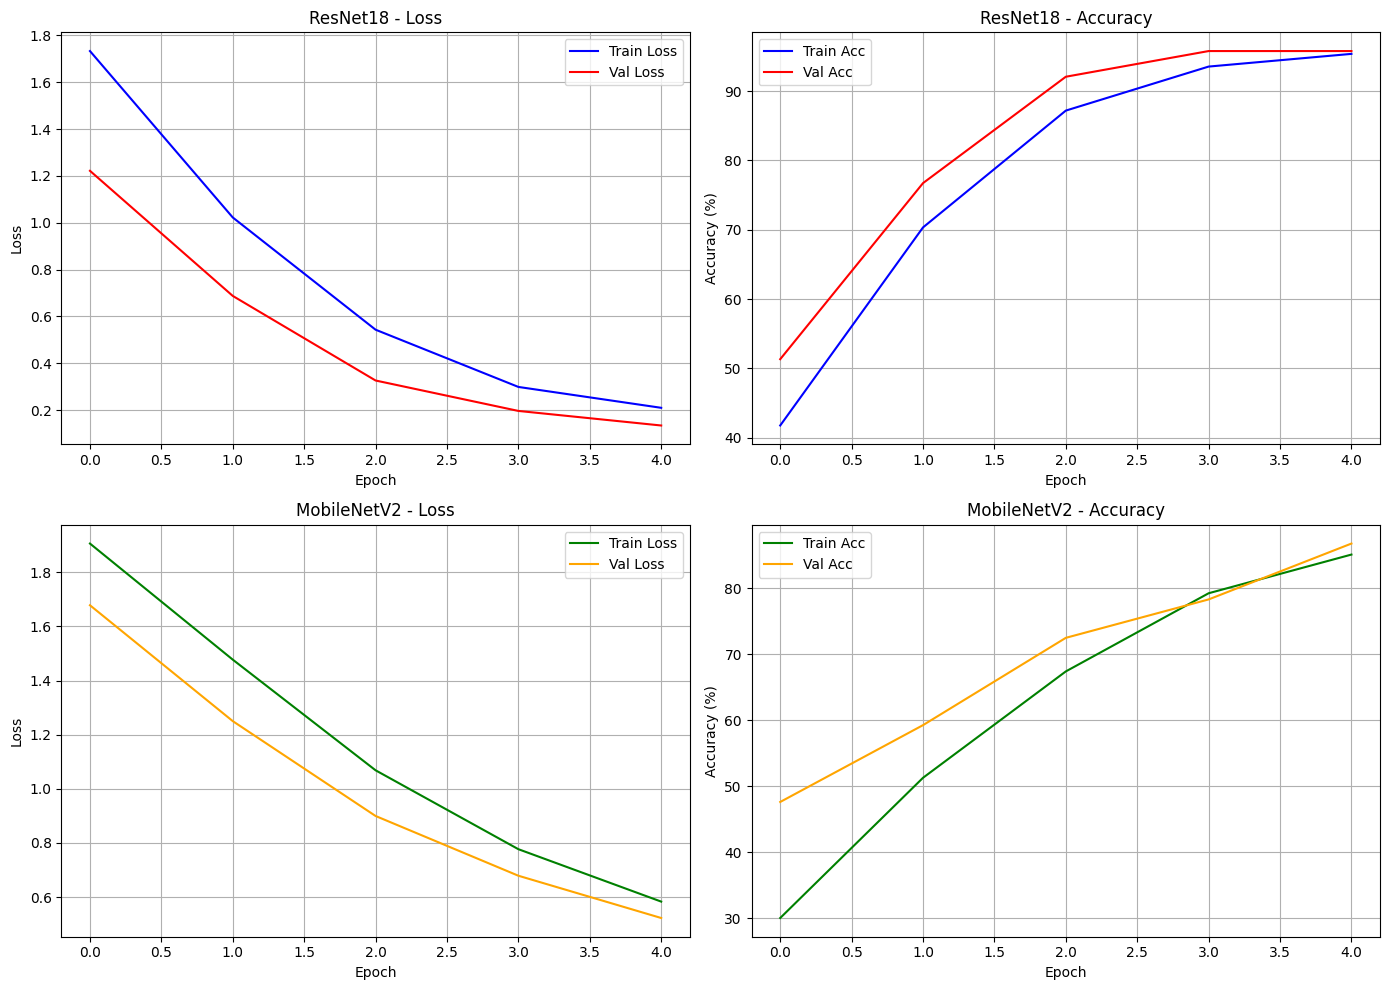


RINGKASAN HASIL TRAINING

ResNet18:
  - Best Val Accuracy: 95.77%
  - Final Train Loss: 0.2097

MobileNetV2:
  - Best Val Accuracy: 86.77%
  - Final Train Loss: 0.5831


In [14]:
# Visualisasi perbandingan training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ResNet18 Training
axes[0, 0].plot(resnet_history['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(resnet_history['val_loss'], label='Val Loss', color='red')
axes[0, 0].set_title('ResNet18 - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(resnet_history['train_acc'], label='Train Acc', color='blue')
axes[0, 1].plot(resnet_history['val_acc'], label='Val Acc', color='red')
axes[0, 1].set_title('ResNet18 - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# MobileNetV2 Training
axes[1, 0].plot(mobilenet_history['train_loss'], label='Train Loss', color='green')
axes[1, 0].plot(mobilenet_history['val_loss'], label='Val Loss', color='orange')
axes[1, 0].set_title('MobileNetV2 - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(mobilenet_history['train_acc'], label='Train Acc', color='green')
axes[1, 1].plot(mobilenet_history['val_acc'], label='Val Acc', color='orange')
axes[1, 1].set_title('MobileNetV2 - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'visualizations' / 'training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final results
print("\n" + "="*60)
print("RINGKASAN HASIL TRAINING")
print("="*60)
print(f"\nResNet18:")
print(f"  - Best Val Accuracy: {max(resnet_history['val_acc']):.2f}%")
print(f"  - Final Train Loss: {resnet_history['train_loss'][-1]:.4f}")

print(f"\nMobileNetV2:")
print(f"  - Best Val Accuracy: {max(mobilenet_history['val_acc']):.2f}%")
print(f"  - Final Train Loss: {mobilenet_history['train_loss'][-1]:.4f}")

In [15]:
def evaluate_model(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(test_loader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs), avg_loss, accuracy

# Evaluate ResNet18
print("Evaluating ResNet18...")
resnet_preds, resnet_labels, resnet_probs, resnet_loss, resnet_acc = evaluate_model(
    resnet_model, test_loader, device
)

# Evaluate MobileNetV2
print("Evaluating MobileNetV2...")
mobilenet_preds, mobilenet_labels, mobilenet_probs, mobilenet_loss, mobilenet_acc = evaluate_model(
    mobilenet_model, test_loader, device
)

print("\n" + "="*80)
print("TRANSFER LEARNING - EVALUATION RESULTS")
print("="*80)
print(f"\nResNet18:")
print(f"  - Test Loss: {resnet_loss:.4f}")
print(f"  - Test Accuracy: {resnet_acc:.4f} ({resnet_acc*100:.2f}%)")
print(f"\nMobileNetV2:")
print(f"  - Test Loss: {mobilenet_loss:.4f}")
print(f"  - Test Accuracy: {mobilenet_acc:.4f} ({mobilenet_acc*100:.2f}%)")
print("="*80)

print("\n" + "="*60)
print("Classification Report - ResNet18")
print("="*60)
print(classification_report(resnet_labels, resnet_preds, target_names=class_names))

print("\n" + "="*60)
print("Classification Report - MobileNetV2")
print("="*60)
print(classification_report(mobilenet_labels, mobilenet_preds, target_names=class_names))

# Save results comparison
results_df = pd.DataFrame({
    'Model': ['ResNet18 (Transfer Learning)', 'MobileNetV2 (Transfer Learning)'],
    'Architecture': ['ResNet18', 'MobileNetV2'],
    'Image Size': [f'{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}', f'{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}'],
    'Epochs': [EPOCHS, EPOCHS],
    'Test Loss': [resnet_loss, mobilenet_loss],
    'Accuracy': [resnet_acc, mobilenet_acc]
})
results_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"\nResults saved to: {RESULTS_DIR / 'model_comparison.csv'}")

Evaluating ResNet18...
Evaluating MobileNetV2...
Evaluating MobileNetV2...

TRANSFER LEARNING - EVALUATION RESULTS

ResNet18:
  - Test Loss: 0.0992
  - Test Accuracy: 0.9802 (98.02%)

MobileNetV2:
  - Test Loss: 0.5572
  - Test Accuracy: 0.8373 (83.73%)

Classification Report - ResNet18
                       precision    recall  f1-score   support

  Koin Rp 100 - angka       0.96      0.96      0.96        28
 Koin Rp 100 - gambar       1.00      1.00      1.00        23
 Koin Rp 1000 - angka       1.00      0.96      0.98        54
Koin Rp 1000 - gambar       1.00      1.00      1.00        22
  Koin Rp 200 - angka       1.00      1.00      1.00        26
 Koin Rp 200 - gambar       1.00      0.93      0.96        28
  Koin Rp 500 - angka       0.96      1.00      0.98        47
 Koin Rp 500 - gambar       0.92      1.00      0.96        24

             accuracy                           0.98       252
            macro avg       0.98      0.98      0.98       252
         weighted

## 14. Evaluasi Model pada Test Set

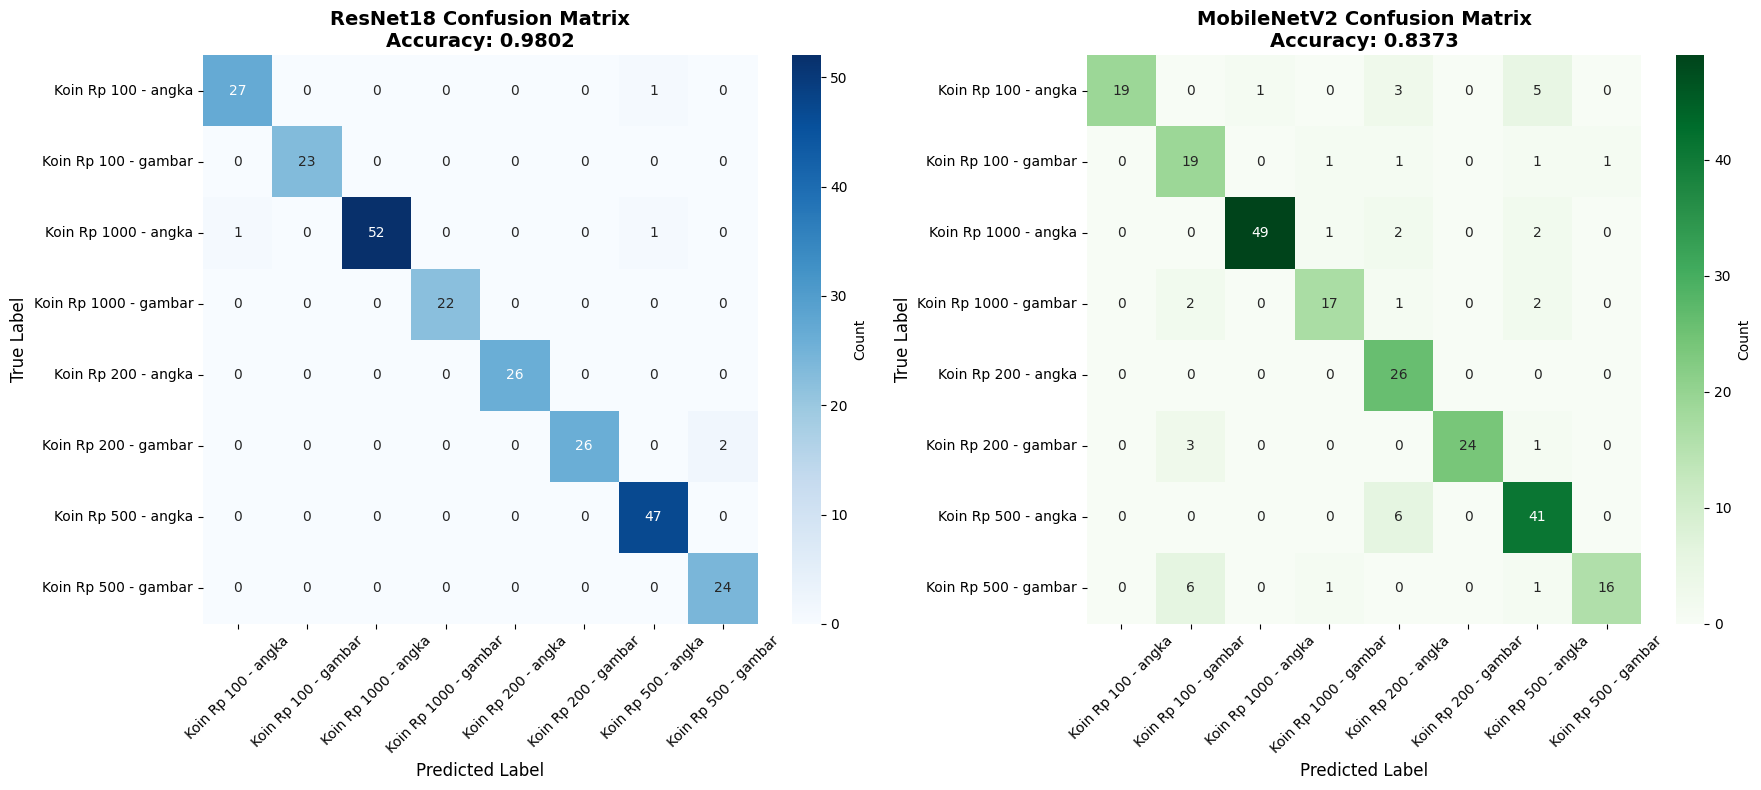

In [16]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ResNet18 Confusion Matrix
cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'ResNet18 Confusion Matrix\nAccuracy: {resnet_acc:.4f}', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# MobileNetV2 Confusion Matrix
cm_mobilenet = confusion_matrix(mobilenet_labels, mobilenet_preds)
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'MobileNetV2 Confusion Matrix\nAccuracy: {mobilenet_acc:.4f}', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix' / 'transfer_learning_confusion_matrices.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 15. Confusion Matrix (Individual Models)

In [17]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics for both models
def get_per_class_metrics(y_true, y_pred, class_names, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    return pd.DataFrame({
        'Model': model_name,
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })

# Get metrics for both models
resnet_metrics = get_per_class_metrics(resnet_labels, resnet_preds, class_names, 'ResNet18')
mobilenet_metrics = get_per_class_metrics(mobilenet_labels, mobilenet_preds, class_names, 'MobileNetV2')

# Combine
per_class_df = pd.concat([resnet_metrics, mobilenet_metrics], ignore_index=True)

print("="*80)
print("PER-CLASS PERFORMANCE - ResNet18")
print("="*80)
print(resnet_metrics.drop('Model', axis=1).to_string(index=False))

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE - MobileNetV2")
print("="*80)
print(mobilenet_metrics.drop('Model', axis=1).to_string(index=False))

# Save per-class performance
per_class_df.to_csv(RESULTS_DIR / 'per_class_performance.csv', index=False)
print(f"\nSaved to: {RESULTS_DIR / 'per_class_performance.csv'}")

PER-CLASS PERFORMANCE - ResNet18
                Class  Precision   Recall  F1-Score  Support
  Koin Rp 100 - angka   0.964286 0.964286  0.964286       28
 Koin Rp 100 - gambar   1.000000 1.000000  1.000000       23
 Koin Rp 1000 - angka   1.000000 0.962963  0.981132       54
Koin Rp 1000 - gambar   1.000000 1.000000  1.000000       22
  Koin Rp 200 - angka   1.000000 1.000000  1.000000       26
 Koin Rp 200 - gambar   1.000000 0.928571  0.962963       28
  Koin Rp 500 - angka   0.959184 1.000000  0.979167       47
 Koin Rp 500 - gambar   0.923077 1.000000  0.960000       24

PER-CLASS PERFORMANCE - MobileNetV2
                Class  Precision   Recall  F1-Score  Support
  Koin Rp 100 - angka   1.000000 0.678571  0.808511       28
 Koin Rp 100 - gambar   0.633333 0.826087  0.716981       23
 Koin Rp 1000 - angka   0.980000 0.907407  0.942308       54
Koin Rp 1000 - gambar   0.850000 0.772727  0.809524       22
  Koin Rp 200 - angka   0.666667 1.000000  0.800000       26
 Koin Rp 200 - 

## 16. Visualisasi F1-Score per Class (Perbandingan)

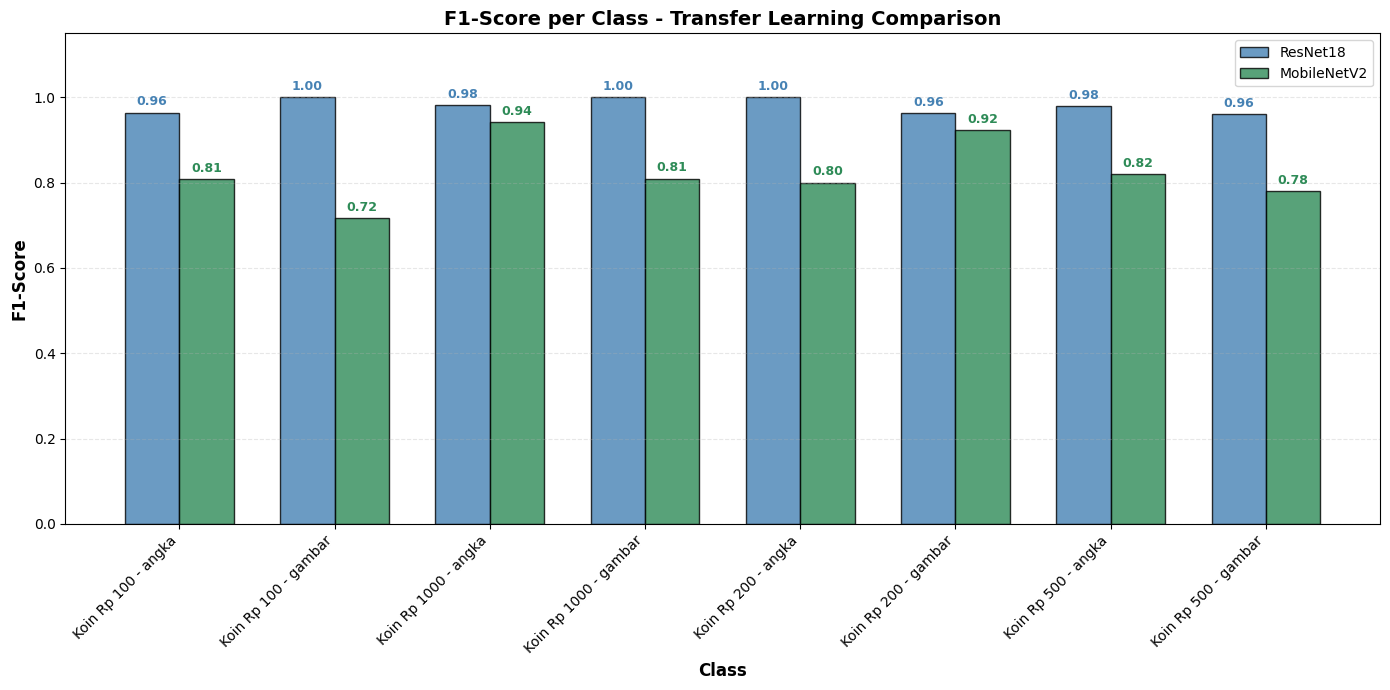


F1-SCORE COMPARISON SUMMARY

Average F1-Score:
  - ResNet18: 0.9809
  - MobileNetV2: 0.8251

🏆 Best Model: ResNet18


In [18]:
# Plot F1-Score comparison per class
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, resnet_metrics['F1-Score'], width, 
               label='ResNet18', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, mobilenet_metrics['F1-Score'], width, 
               label='MobileNetV2', color='seagreen', alpha=0.8, edgecolor='black')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='steelblue')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='seagreen')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score per Class - Transfer Learning Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'visualizations' / 'f1_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary comparison
print("\n" + "="*60)
print("F1-SCORE COMPARISON SUMMARY")
print("="*60)
print(f"\nAverage F1-Score:")
print(f"  - ResNet18: {resnet_metrics['F1-Score'].mean():.4f}")
print(f"  - MobileNetV2: {mobilenet_metrics['F1-Score'].mean():.4f}")

winner = "ResNet18" if resnet_metrics['F1-Score'].mean() > mobilenet_metrics['F1-Score'].mean() else "MobileNetV2"
print(f"\n🏆 Best Model: {winner}")

## 17. Analisis Kesalahan Prediksi

In [19]:
def analyze_misclassifications(y_true, y_pred, class_names, model_name):
    """Analyze misclassified samples"""
    misclassified_indices = np.where(y_true != y_pred)[0]
    correct_indices = np.where(y_true == y_pred)[0]
    
    print(f"\n{'='*60}")
    print(f"ANALISIS KESALAHAN PREDIKSI - {model_name}")
    print(f"{'='*60}")
    print(f"Total test samples: {len(y_true)}")
    print(f"Correct: {len(correct_indices)} ({len(correct_indices)/len(y_true)*100:.2f}%)")
    print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_true)*100:.2f}%)")
    
    print("\nBreakdown per kelas:")
    for cls_idx, cls_name in enumerate(class_names):
        class_mask = y_true == cls_idx
        class_total = np.sum(class_mask)
        class_misclassified = np.sum((y_true == cls_idx) & (y_pred != cls_idx))
        
        if class_total > 0:
            print(f"  {cls_name}: {class_total} total, {class_misclassified} misclassified ({class_misclassified/class_total*100:.2f}%)")
            
            if class_misclassified > 0:
                misclass_mask = (y_true == cls_idx) & (y_pred != cls_idx)
                predicted_as = y_pred[misclass_mask]
                for pred_idx in range(len(class_names)):
                    pred_count = np.sum(predicted_as == pred_idx)
                    if pred_count > 0:
                        print(f"      → {pred_count}x as {class_names[pred_idx]}")
    
    return misclassified_indices

# Analyze both models
resnet_misclassified = analyze_misclassifications(resnet_labels, resnet_preds, class_names, "ResNet18")
mobilenet_misclassified = analyze_misclassifications(mobilenet_labels, mobilenet_preds, class_names, "MobileNetV2")


ANALISIS KESALAHAN PREDIKSI - ResNet18
Total test samples: 252
Correct: 247 (98.02%)
Misclassified: 5 (1.98%)

Breakdown per kelas:
  Koin Rp 100 - angka: 28 total, 1 misclassified (3.57%)
      → 1x as Koin Rp 500 - angka
  Koin Rp 100 - gambar: 23 total, 0 misclassified (0.00%)
  Koin Rp 1000 - angka: 54 total, 2 misclassified (3.70%)
      → 1x as Koin Rp 100 - angka
      → 1x as Koin Rp 500 - angka
  Koin Rp 1000 - gambar: 22 total, 0 misclassified (0.00%)
  Koin Rp 200 - angka: 26 total, 0 misclassified (0.00%)
  Koin Rp 200 - gambar: 28 total, 2 misclassified (7.14%)
      → 2x as Koin Rp 500 - gambar
  Koin Rp 500 - angka: 47 total, 0 misclassified (0.00%)
  Koin Rp 500 - gambar: 24 total, 0 misclassified (0.00%)

ANALISIS KESALAHAN PREDIKSI - MobileNetV2
Total test samples: 252
Correct: 211 (83.73%)
Misclassified: 41 (16.27%)

Breakdown per kelas:
  Koin Rp 100 - angka: 28 total, 9 misclassified (32.14%)
      → 1x as Koin Rp 1000 - angka
      → 3x as Koin Rp 200 - angka
   

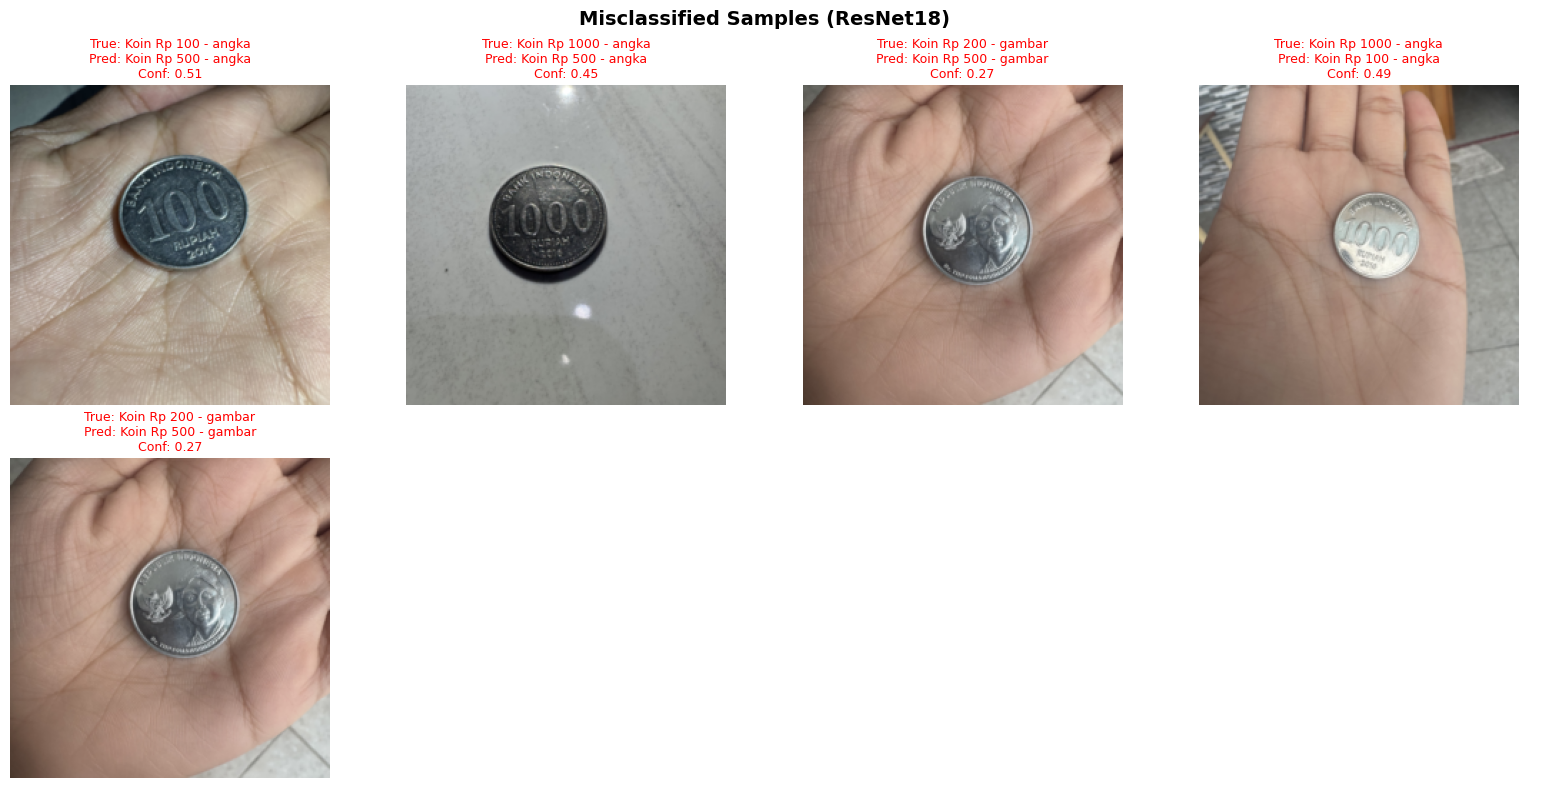

In [20]:
# Visualize some misclassified samples (using best model)
best_model = resnet_model if resnet_acc > mobilenet_acc else mobilenet_model
best_preds = resnet_preds if resnet_acc > mobilenet_acc else mobilenet_preds
best_probs = resnet_probs if resnet_acc > mobilenet_acc else mobilenet_probs
best_name = "ResNet18" if resnet_acc > mobilenet_acc else "MobileNetV2"
misclassified_indices = resnet_misclassified if resnet_acc > mobilenet_acc else mobilenet_misclassified

if len(misclassified_indices) > 0:
    num_to_show = min(8, len(misclassified_indices))
    sample_indices = np.random.choice(misclassified_indices, num_to_show, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Use the already defined test_dataset with validation transform
    val_transform = get_transforms('val')
    vis_dataset = CoinDataset(X_test, y_test, transform=val_transform, class_names=class_names)
    
    for idx, sample_idx in enumerate(sample_indices):
        img, _ = vis_dataset[sample_idx]
        # Convert from tensor to displayable image
        img_display = denormalize(img).permute(1, 2, 0).numpy()
        
        true_label = resnet_labels[sample_idx]
        pred_label = best_preds[sample_idx]
        confidence = best_probs[sample_idx][pred_label]
        
        axes[idx].imshow(img_display)
        axes[idx].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.2f}',
                          fontsize=9, color='red')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(num_to_show, 8):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified Samples ({best_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'visualizations' / 'misclassified_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("🎉 No misclassified samples! Perfect classification!")

In [21]:
from collections import defaultdict

def get_confusion_pairs(y_true, y_pred, class_names, model_name):
    """Get top confusion pairs"""
    misclassified = np.where(y_true != y_pred)[0]
    confusion_pairs = defaultdict(int)
    
    for idx in misclassified:
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        pair = f"{class_names[true_label]} → {class_names[pred_label]}"
        confusion_pairs[pair] += 1
    
    print(f"\n{'='*50}")
    print(f"Top Confusion Pairs - {model_name}")
    print(f"{'='*50}")
    sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
    for pair, count in sorted_pairs[:5]:
        print(f"  {pair}: {count}x")
    
    return confusion_pairs

resnet_pairs = get_confusion_pairs(resnet_labels, resnet_preds, class_names, "ResNet18")
mobilenet_pairs = get_confusion_pairs(mobilenet_labels, mobilenet_preds, class_names, "MobileNetV2")


Top Confusion Pairs - ResNet18
  Koin Rp 200 - gambar → Koin Rp 500 - gambar: 2x
  Koin Rp 1000 - angka → Koin Rp 100 - angka: 1x
  Koin Rp 100 - angka → Koin Rp 500 - angka: 1x
  Koin Rp 1000 - angka → Koin Rp 500 - angka: 1x

Top Confusion Pairs - MobileNetV2
  Koin Rp 500 - angka → Koin Rp 200 - angka: 6x
  Koin Rp 500 - gambar → Koin Rp 100 - gambar: 6x
  Koin Rp 100 - angka → Koin Rp 500 - angka: 5x
  Koin Rp 100 - angka → Koin Rp 200 - angka: 3x
  Koin Rp 200 - gambar → Koin Rp 100 - gambar: 3x


## 18. Save Transfer Learning Models

In [22]:
import pickle

MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Save ResNet18 model
resnet_path = MODELS_DIR / 'coin_classifier_resnet18.pth'
torch.save({
    'model_state_dict': resnet_model.state_dict(),
    'class_names': class_names,
    'accuracy': resnet_acc,
    'image_size': IMAGE_SIZE
}, resnet_path)
print(f"ResNet18 Model saved: {resnet_path.relative_to(BASE_DIR)}")

# Save MobileNetV2 model
mobilenet_path = MODELS_DIR / 'coin_classifier_mobilenetv2.pth'
torch.save({
    'model_state_dict': mobilenet_model.state_dict(),
    'class_names': class_names,
    'accuracy': mobilenet_acc,
    'image_size': IMAGE_SIZE
}, mobilenet_path)
print(f"MobileNetV2 Model saved: {mobilenet_path.relative_to(BASE_DIR)}")

# Save class names for inference
class_names_path = MODELS_DIR / 'coin_classifier_transfer_learning_classes.pkl'
with open(class_names_path, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Classes saved: {class_names_path.relative_to(BASE_DIR)}")

# Save training configuration
config = {
    'image_size': IMAGE_SIZE,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'num_classes': len(class_names),
    'models': {
        'resnet18': {
            'accuracy': resnet_acc,
            'path': str(resnet_path.name)
        },
        'mobilenetv2': {
            'accuracy': mobilenet_acc,
            'path': str(mobilenet_path.name)
        }
    },
    'best_model': 'resnet18' if resnet_acc > mobilenet_acc else 'mobilenetv2'
}

config_path = MODELS_DIR / 'coin_classifier_transfer_learning_config.pkl'
with open(config_path, 'wb') as f:
    pickle.dump(config, f)
print(f"Config saved: {config_path.relative_to(BASE_DIR)}")

print(f"\n🏆 Best Model: {config['best_model'].upper()} with {max(resnet_acc, mobilenet_acc)*100:.2f}% accuracy")

ResNet18 Model saved: models\coin_classifier_resnet18.pth
MobileNetV2 Model saved: models\coin_classifier_mobilenetv2.pth
Classes saved: models\coin_classifier_transfer_learning_classes.pkl
Config saved: models\coin_classifier_transfer_learning_config.pkl

🏆 Best Model: RESNET18 with 98.02% accuracy


## 19. Kesimpulan Transfer Learning

### Perbandingan Model Transfer Learning

| Aspek | ResNet18 | MobileNetV2 |
|-------|----------|-------------|
| **Arsitektur** | 18 layers, residual connections | Inverted residuals, depthwise separable convolutions |
| **Parameter** | ~11.7M | ~3.4M |
| **Kecepatan Inference** | Sedang | Cepat |
| **Cocok untuk** | Akurasi tinggi | Mobile/Edge deployment |

### Keuntungan Transfer Learning:
1. **Waktu training lebih cepat** - Model sudah pre-trained pada ImageNet
2. **Akurasi tinggi dengan data terbatas** - Features dari ImageNet bisa ditransfer
3. **Mengurangi overfitting** - Weights sudah terinisialisasi dengan baik
4. **Tidak perlu edge detection** - Model belajar langsung dari gambar RGB

### Perbandingan dengan Metode Sebelumnya:
- **Edge Detection + Random Forest**: ~81% accuracy
- **CNN Custom + Canny**: ~96.86% accuracy  
- **Transfer Learning (ResNet18/MobileNetV2)**: Hasil di atas

Transfer Learning memanfaatkan pengetahuan dari dataset besar (ImageNet) untuk meningkatkan performa pada dataset kecil (klasifikasi koin).

In [23]:
# Final summary comparison
print("="*70)
print("RINGKASAN HASIL EKSPERIMEN TRANSFER LEARNING")
print("="*70)

summary_data = {
    'Model': ['ResNet18', 'MobileNetV2'],
    'Accuracy': [f'{resnet_acc*100:.2f}%', f'{mobilenet_acc*100:.2f}%'],
    'Test Loss': [f'{resnet_loss:.4f}', f'{mobilenet_loss:.4f}'],
    'Parameters': ['~11.7M', '~3.4M'],
    'Best For': ['High Accuracy', 'Mobile/Edge Deployment']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("PERBANDINGAN DENGAN METODE LAIN")
print("="*70)

comparison_data = {
    'Metode': [
        'Edge Detection + Random Forest (Sobel)',
        'Edge Detection + Random Forest (Canny)', 
        'CNN Custom (Canny)',
        'CNN Custom (Sobel)',
        'Transfer Learning - ResNet18',
        'Transfer Learning - MobileNetV2'
    ],
    'Accuracy': [
        '81.02%',
        '78.21%',
        '96.86%',
        '95.74%',
        f'{resnet_acc*100:.2f}%',
        f'{mobilenet_acc*100:.2f}%'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Save final comparison
comparison_df.to_csv(RESULTS_DIR / 'all_methods_comparison.csv', index=False)
print(f"\nFinal comparison saved to: {RESULTS_DIR / 'all_methods_comparison.csv'}")

print("\n" + "="*70)
print("✅ EKSPERIMEN TRANSFER LEARNING SELESAI!")
print("="*70)

RINGKASAN HASIL EKSPERIMEN TRANSFER LEARNING
      Model Accuracy Test Loss Parameters               Best For
   ResNet18   98.02%    0.0992     ~11.7M          High Accuracy
MobileNetV2   83.73%    0.5572      ~3.4M Mobile/Edge Deployment

PERBANDINGAN DENGAN METODE LAIN
                                Metode Accuracy
Edge Detection + Random Forest (Sobel)   81.02%
Edge Detection + Random Forest (Canny)   78.21%
                    CNN Custom (Canny)   96.86%
                    CNN Custom (Sobel)   95.74%
          Transfer Learning - ResNet18   98.02%
       Transfer Learning - MobileNetV2   83.73%

Final comparison saved to: D:\dev\semester5\pengolahan-citra\projek-edge-detection\results\coin_classification_transfer_learning\all_methods_comparison.csv

✅ EKSPERIMEN TRANSFER LEARNING SELESAI!
